             Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1  01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2  01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
3  01.01.2009 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
4  01.01.2009 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02   
3          3.26          3.07          0.19       1.92             3.08   
4          3.27          3.08          0.19       1.92             3.09   

   rho (g/m**3)  wv (m/s)  max. wv (m/s)  wd (deg)  
0       1307.75      1.03        

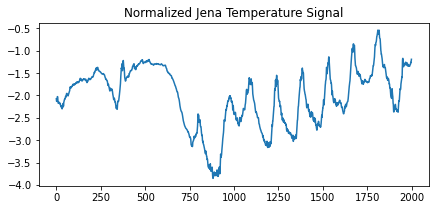

In [3]:
# Jena dataset for quantum paper
# Dataset link: https://www.tensorflow.org/tutorials/structured_data/time_series 
# Check the code snippet for the url 
'''
zip_path = tf.keras.utils.get_file(
    origin='https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
    fname='jena_climate_2009_2016.csv.zip',
    extract=True)
csv_path, _ = os.path.splitext(zip_path)
'''
# ======================================================== 
# JENA climate dataset + qrc / esn forecasting pipeline
# ========================================================

# Step 1: Fetch the dataset from the above link. Manually extract. 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
# Note later if you have time try with other plot techniques  like seaborn or d3.js

# Load the csv dataset
df = pd.read_csv("jena_climate_2009_2016.csv")

print(df.head())
print(df.columns)

# Step 2: Choose teh target variable . Temperature is std benchmark target
y_raw = df["T (degC)"].values.astype(np.float32)
# normalize
y = (y_raw - y_raw.mean()) / (y_raw.std() + 1e-12)

plt.figure(figsize=(7,3))
plt.plot(y[:2000])
plt.title("Normalized Jena Temperature Signal")
plt.show() 

# Step 3: Define Rservoir
class ESN:
    def __init__(self, N_res=500, rho=0.95,leak=0.3,in_scale=0.6,connectivity=0.03,seed=42):
        rng = np.random.default_rng(seed)
        self.N_res = N_res
        self.leak = leak
        
        # Sparse reservoir
        W = rng.standard_normal((N_res,N_res))
        
        mask = rng.random((N_res, N_res)) < connectivity
        W *= mask
        
        #spectral radius normalization
        eigvals = np.linalg.eigvals(W)
        W *= rho / np.max(np.abs(eigvals))
        
        self.W =W
        self.Win = rng.standard_normal((N_res, 1)) * in_scale
        
    def step(self, x,u):
        pre = self.W @ x + self.Win[:,0] * u
        x_new = (1 - self.leak) * x + self.leak *np.tanh(pre)
            
        return x_new

    

In [6]:
# Step 4: Run the reservoir & collect states
reservoir = ESN(N_res=500, rho=0.95, leak=0.3, in_scale=0.6, connectivity=0.03, seed=42)
def run_reservoir(reservoir, signal):
    x = np.zeros(reservoir.N_res)
    states = []
    
    for u in signal:
        x = reservoir.step(x, u)
        states.append(x.copy())
    
    return np.array(states)
states = run_reservoir(reservoir, y)
print("Reservoir states shape:", states.shape)

# -----------------------------------------------------
# Step 5: Washout -- refer your paper why you are using washout. 
#         Note: you found an issue if not using washout 
# -----------------------------------------------------
washout = 200

X = states[washout:]
y_w = y[washout:]

# Build one-step pairs
X_all = X[:-1]
y_next = y_w[1:]

# ---------------------------------------
# Step 6: Train / Validate / Test split
# ---------------------------------------
L = len(y_next)
n_train = int(0.6 * L)
n_valid = int(0.2 * L)
n_test = L - n_train - n_valid

# Train
Xtr = X_all[:n_train]
tgt_tr = y_next[:n_train]
# Validation
Xva = X_all[n_train:n_train+n_valid]
tgt_va = y_next[n_train:n_train+n_valid]
# Test
Xte = X_all[n_train+n_valid:]
tgt_te = y_next[n_train+n_valid:]
print("Train shapes:", Xtr.shape, tgt_tr.shape)
print("Valid shapes:", Xva.shape, tgt_va.shape)
print("Test shapes:", Xte.shape, tgt_te.shape)

##############################
# Step 7: Standardise feature
# ##########
mu = Xtr.mean(axis=0, keepdims=True)
sd = Xtr.std(axis=0, keepdims=True) + 1e-12

xtr = (Xtr - mu) / sd
xva = (Xva - mu) / sd
xte = (Xte - mu) / sd

#####################################
# step 8: Ridge readout
#####################################
def add_bias(A):
    return np.hstack([A, np.ones((A.shape[0], 1))]) 

Xtr_b = add_bias(Xtr)
Xva_b = add_bias(Xva)
Xte_b = add_bias(Xte)

lam_grid = [0.0,1e-6, 1e-5, 1e-4, 1e-3]

best = None
# XtX = Xtr_b.T @ Xtr_b
# for lam in lam_grid:
#     Wout = (tgt_tr @ Xtr_b) @ np.linalg.inv(XtX + lam * np.eye(Xtr_b.shape[0]))
#     yhat_va = Xva_b @ Wout.T
#     nrmse_va = np.linalg.norm(yhat_va - tgt_va) / (np.linalg.norm(tgt_va) + 1e-12)
    
#     if best is None or nrmse_va < best[0]:
#         best = (nrmse_va, lam, Wout)
#     """ 
#     if best is None:
#         best = (nrmse_va, lam, Wout)
#     elif nrmse_va < best[0]:
#         best = (nrmse_va, lam, Wout)        
#     """
#     print("The value of best[0] is:", best[0])
######## was seeing the error
# MemoryError: Unable to allocate 474. GiB for an array with shape (252210, 252210) and data type float64
########## so try below
XtX = Xtr_b.T @ Xtr_b
I = np.eye(XtX.shape[0])
for lam in lam_grid:
    Wout = np.linalg.solve(XtX + lam * I, Xtr_b.T @ tgt_tr)
    yhat_va = Xva_b @ Wout
    nrmse_va = np.linalg.norm(yhat_va - tgt_va) / (np.linalg.norm(tgt_va) + 1e-12)
    if best is None or nrmse_va < best[0]:
        best = (nrmse_va, lam, Wout)
    print("The value of best[0] is:", best[0])    

nrmse_va, lam_star, Wout = best 
print("Validation NRMSE:", nrmse_va)
print("Best lambda:", lam_star)



Reservoir states shape: (420551, 500)
Train shapes: (252210, 500) (252210,)
Valid shapes: (84070, 500) (84070,)
Test shapes: (84070, 500) (84070,)
The value of best[0] is: 0.028271788361251892
The value of best[0] is: 0.0282562981903163
The value of best[0] is: 0.028193378072654873
The value of best[0] is: 0.028193378072654873
The value of best[0] is: 0.028193378072654873
Validation NRMSE: 0.028193378072654873
Best lambda: 1e-05


Test NRMSE: 0.02519866775833479


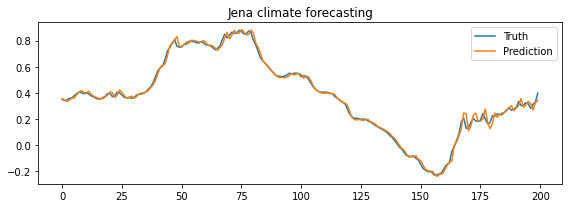

In [7]:
# ---------------------------------------
# Step 9: TEst forecasting performance
# ---------------------------------------
yhat_te = Xte_b @ Wout.T
nrmse_te = np.linalg.norm(yhat_te - tgt_te) / (np.linalg.norm(tgt_te) + 1e-12)
print("Test NRMSE:", nrmse_te)

# ----------------------------------------- 
# Step 10: Plots    
# -----------------------------------------
plt.figure(figsize=(8,3))
plt.plot(tgt_te[:200], label="Truth")
plt.plot(yhat_te[:200], label="Prediction") # ESN Forecast")
plt.legend()
# plt.xlabel("Time")
# plt.ylabel("Value")
plt.title("Jena climate forecasting") #ESN Forecasting Performance")
plt.tight_layout()
plt.show()